saved fig_host_pretty.{pdf,png}


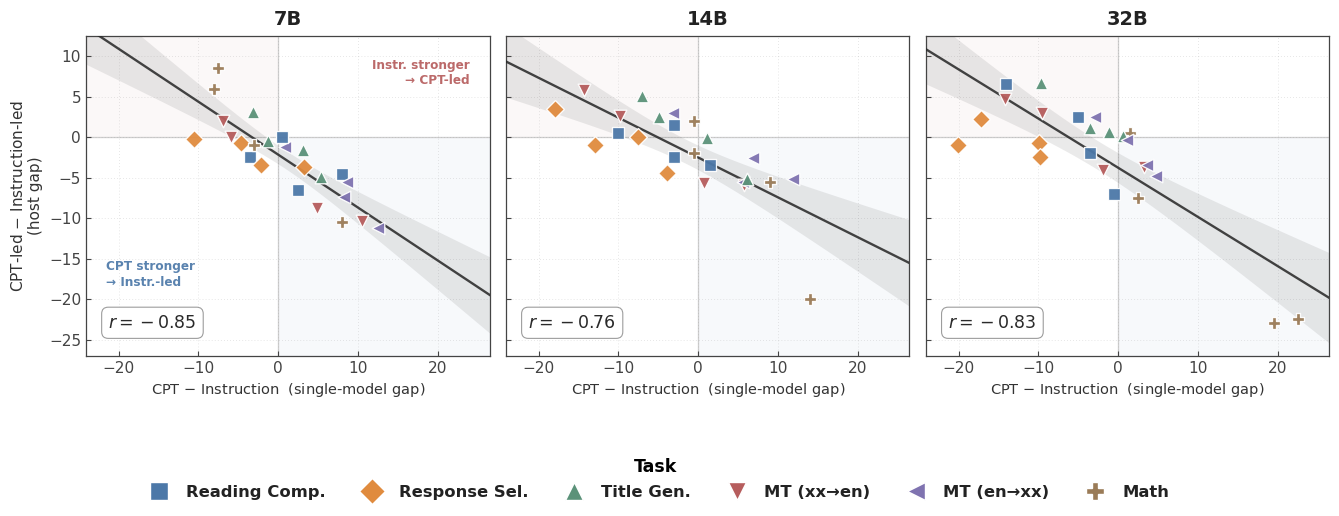

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import pearsonr, t as tdist

# ============ 数据 ============
# 1.5B-cpt 单模型
cpt_solo = {
    'bo': {'rc': 43.5, 'rs': 32.4, 'title': 28.0, 'x2e': 7.1,  'e2x': 16.3, 'math': 5.0},
    'ug': {'rc': 65.0, 'rs': 45.7, 'title': 16.7, 'x2e': 36.5, 'e2x': 20.0, 'math': 27.0},
    'mn': {'rc': 44.5, 'rs': 28.7, 'title': 14.7, 'x2e': 6.3,  'e2x': 12.6, 'math': 4.5},
    'kk': {'rc': 55.0, 'rs': 43.5, 'title': 22.5, 'x2e': 25.5, 'e2x': 12.9, 'math': 21.0},
}

# 纯 instruction 单模型
ins_solo = {
    ('bo', 7):  {'rc': 47.0, 'rs': 37.1, 'title': 29.3, 'x2e': 13.0, 'e2x': 15.4, 'math': 13.0},
    ('bo', 14): {'rc': 53.5, 'rs': 40.0, 'title': 32.9, 'x2e': 21.4, 'e2x': 19.4, 'math': 5.5},
    ('bo', 32): {'rc': 57.5, 'rs': 42.3, 'title': 31.5, 'x2e': 21.3, 'e2x': 19.2, 'math': 2.5},

    ('ug', 7):  {'rc': 57.0, 'rs': 47.9, 'title': 19.9, 'x2e': 26.0, 'e2x': 11.8, 'math': 30.0},
    ('ug', 14): {'rc': 63.5, 'rs': 58.7, 'title': 23.8, 'x2e': 30.7, 'e2x': 14.4, 'math': 13.0},
    ('ug', 32): {'rc': 65.5, 'rs': 65.8, 'title': 26.4, 'x2e': 33.3, 'e2x': 16.4, 'math': 4.5},

    ('mn', 7):  {'rc': 44.0, 'rs': 39.3, 'title': 11.6, 'x2e': 13.2, 'e2x': 4.0, 'math': 12.0},
    ('mn', 14): {'rc': 47.5, 'rs': 46.7, 'title': 13.6, 'x2e': 16.1, 'e2x': 0.7, 'math': 5.0},
    ('mn', 32): {'rc': 49.5, 'rs': 45.9, 'title': 15.9, 'x2e': 15.8, 'e2x': 7.9, 'math': 3.0},

    ('kk', 7):  {'rc': 52.5, 'rs': 40.3, 'title': 17.1, 'x2e': 20.6, 'e2x': 0.4, 'math': 13.0},
    ('kk', 14): {'rc': 58.0, 'rs': 47.4, 'title': 16.4, 'x2e': 24.8, 'e2x': 6.0, 'math': 12.0},
    ('kk', 32): {'rc': 58.5, 'rs': 53.3, 'title': 21.9, 'x2e': 27.4, 'e2x': 11.8, 'math': 1.5},
}

# SAF-W instruction-led
ins_led = {
    ('bo', 7):  {'rc': 49.0, 'rs': 38.3, 'title': 29.3, 'x2e': 13.3, 'e2x': 15.8, 'math': 7.5},
    ('bo', 14): {'rc': 52.5, 'rs': 39.6, 'title': 29.6, 'x2e': 15.8, 'e2x': 15.9, 'math': 10.0},
    ('bo', 32): {'rc': 52.0, 'rs': 41.5, 'title': 32.4, 'x2e': 16.4, 'e2x': 16.1, 'math': 9.0},

    ('ug', 7):  {'rc': 62.5, 'rs': 51.3, 'title': 16.9, 'x2e': 37.7, 'e2x': 19.2, 'math': 34.0},
    ('ug', 14): {'rc': 69.5, 'rs': 59.7, 'title': 18.5, 'x2e': 38.1, 'e2x': 20.7, 'math': 35.5},
    ('ug', 32): {'rc': 73.0, 'rs': 67.6, 'title': 17.9, 'x2e': 38.4, 'e2x': 21.1, 'math': 30.5},

    ('mn', 7):  {'rc': 44.0, 'rs': 41.5, 'title': 15.2, 'x2e': 11.9, 'e2x': 11.5, 'math': 7.0},
    ('mn', 14): {'rc': 46.0, 'rs': 41.5, 'title': 14.9, 'x2e': 13.2, 'e2x': 11.3, 'math': 4.5},
    ('mn', 32): {'rc': 47.0, 'rs': 43.7, 'title': 15.5, 'x2e': 12.4, 'e2x': 12.4, 'math': 4.5},

    ('kk', 7):  {'rc': 60.5, 'rs': 43.5, 'title': 23.8, 'x2e': 30.2, 'e2x': 12.3, 'math': 26.5},
    ('kk', 14): {'rc': 61.0, 'rs': 52.1, 'title': 24.9, 'x2e': 31.4, 'e2x': 12.3, 'math': 24.0},
    ('kk', 32): {'rc': 61.0, 'rs': 55.3, 'title': 24.1, 'x2e': 32.6, 'e2x': 13.2, 'math': 25.0},
}

# SAF-W cpt-led
cpt_led = {
    ('bo', 7):  {'rc': 46.5, 'rs': 37.6, 'title': 28.8, 'x2e': 13.3, 'e2x': 14.6, 'math': 13.5},
    ('bo', 14): {'rc': 53.0, 'rs': 39.6, 'title': 32.1, 'x2e': 21.6, 'e2x': 18.9, 'math': 8.0},
    ('bo', 32): {'rc': 58.5, 'rs': 40.8, 'title': 33.5, 'x2e': 21.1, 'e2x': 18.6, 'math': 1.5},

    ('ug', 7):  {'rc': 58.0, 'rs': 47.9, 'title': 20.0, 'x2e': 27.4, 'e2x': 11.8, 'math': 33.0},
    ('ug', 14): {'rc': 66.0, 'rs': 58.7, 'title': 23.6, 'x2e': 32.2, 'e2x': 15.2, 'math': 15.5},
    ('ug', 32): {'rc': 66.0, 'rs': 66.6, 'title': 24.6, 'x2e': 34.7, 'e2x': 17.7, 'math': 8.0},

    ('mn', 7):  {'rc': 44.0, 'rs': 41.3, 'title': 13.6, 'x2e': 13.9, 'e2x': 6.0, 'math': 15.5},
    ('mn', 14): {'rc': 47.5, 'rs': 45.0, 'title': 14.8, 'x2e': 15.8, 'e2x': 6.1, 'math': 6.5},
    ('mn', 32): {'rc': 49.5, 'rs': 46.0, 'title': 16.1, 'x2e': 15.4, 'e2x': 7.6, 'math': 5.0},

    ('kk', 7):  {'rc': 54.0, 'rs': 39.8, 'title': 18.9, 'x2e': 21.5, 'e2x': 1.1, 'math': 16.0},
    ('kk', 14): {'rc': 58.5, 'rs': 47.7, 'title': 19.7, 'x2e': 25.7, 'e2x': 9.7, 'math': 18.5},
    ('kk', 32): {'rc': 59.0, 'rs': 52.8, 'title': 24.2, 'x2e': 28.6, 'e2x': 12.8, 'math': 2.0},
}

# ============ 设置 ============
tasks = ['rc', 'rs', 'title', 'x2e', 'e2x', 'math']
task_label = {
    'rc': 'Reading Comp.',
    'rs': 'Response Sel.',
    'title': 'Title Gen.',
    'x2e': 'MT (xx→en)',
    'e2x': 'MT (en→xx)',
    'math': 'Math',
}
colors = {
    'rc': '#4C78A8',
    'rs': '#E08B3E',
    'title': '#5B9279',
    'x2e': '#B65D5D',
    'e2x': '#7F73B0',
    'math': '#9A7B57',
}
task_marker = {
    'rc': 's',    # square
    'rs': 'D',    # diamond
    'title': '^', # triangle up
    'x2e': 'v',   # triangle down
    'e2x': '<',   # triangle left
    'math': 'P',  # filled plus
}

langs = ['bo', 'ug', 'mn', 'kk']
sizes = [7, 14, 32]

plt.rcParams.update({
    'font.size': 11,
    'font.family': 'DejaVu Sans',
    'axes.linewidth': 0.9,
    'axes.edgecolor': '#444444',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3.5,
    'ytick.major.size': 3.5,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# ============ 画布 ============
fig, axes = plt.subplots(
    1, 3,
    figsize=(13.8, 4.8),
    sharex=True,
    sharey=True
)
fig.patch.set_facecolor('white')

allX = [
    cpt_solo[lg][t] - ins_solo[(lg, sz)][t]
    for sz in sizes for lg in langs for t in tasks
]
allY = [
    cpt_led[(lg, sz)][t] - ins_led[(lg, sz)][t]
    for sz in sizes for lg in langs for t in tasks
]
xlo, xhi = min(allX) - 4, max(allX) + 4
ylo, yhi = min(allY) - 4, max(allY) + 4

def conf_band(X, Y, xs):
    n = len(X)
    m, b = np.polyfit(X, Y, 1)
    yhat = m * X + b
    resid = Y - yhat
    s_err = np.sqrt(np.sum(resid**2) / (n - 2))
    xmean = np.mean(X)
    ssx = np.sum((X - xmean)**2)
    tval = tdist.ppf(0.975, n - 2)
    se = s_err * np.sqrt(1 / n + (xs - xmean)**2 / ssx)
    return m * xs + b, tval * se

# ============ 子图 ============
for ax, sz in zip(axes, sizes):
    X = np.array([
        cpt_solo[lg][t] - ins_solo[(lg, sz)][t]
        for lg in langs for t in tasks
    ])
    Y = np.array([
        cpt_led[(lg, sz)][t] - ins_led[(lg, sz)][t]
        for lg in langs for t in tasks
    ])
    TL = [(lg, t) for lg in langs for t in tasks]
    r, _ = pearsonr(X, Y)

    # 柔和象限底色
    ax.fill_between([0, xhi], ylo, 0, color='#4C78A8', alpha=0.045, zorder=0)
    ax.fill_between([xlo, 0], 0, yhi, color='#B65D5D', alpha=0.045, zorder=0)

    # 零线
    ax.axhline(0, color='#CFCFCF', lw=0.9, zorder=1)
    ax.axvline(0, color='#CFCFCF', lw=0.9, zorder=1)

    # 回归线 + 95% CI
    xs = np.linspace(xlo, xhi, 120)
    yfit, ci = conf_band(X, Y, xs)
    ax.fill_between(xs, yfit - ci, yfit + ci, color='#555555', alpha=0.12, zorder=2, lw=0)
    ax.plot(xs, yfit, '-', color='#2A2A2A', lw=1.7, zorder=3, alpha=0.88)

    # 散点：非圆形 marker
    for x, y, (lg, t) in zip(X, Y, TL):
        ax.scatter(
            x, y,
            s=82,
            c=colors[t],
            marker=task_marker[t],
            edgecolors='white',
            linewidths=0.95,
            zorder=5,
            alpha=0.95
        )

    ax.set_xlim(xlo, xhi)
    ax.set_ylim(ylo, yhi)
    ax.set_title(f'{sz}B', fontsize=14, fontweight='bold', pad=8, color='#222222')

    ax.text(
        0.055, 0.075, f'$r = {r:.2f}$',
        transform=ax.transAxes,
        fontsize=12.5,
        fontweight='bold',
        va='bottom',
        color='#2A2A2A',
        bbox=dict(
            boxstyle='round,pad=0.38',
            fc='white',
            ec='#999999',
            lw=0.8,
            alpha=0.96
        )
    )

    ax.grid(True, ls=(0, (1, 3)), lw=0.55, alpha=0.38, zorder=0, color='#999999')
    ax.set_xlabel('CPT $-$ Instruction  (single-model gap)', fontsize=10.5, color='#333333')
    ax.tick_params(colors='#444444')

# 象限注释
axes[0].text(
    0.95, 0.93, 'Instr. stronger\n→ CPT-led',
    transform=axes[0].transAxes,
    fontsize=8.7,
    ha='right',
    va='top',
    color='#B65D5D',
    fontweight='bold',
    linespacing=1.25,
    alpha=0.92
)
axes[0].text(
    0.05, 0.30, 'CPT stronger\n→ Instr.-led',
    transform=axes[0].transAxes,
    fontsize=8.7,
    ha='left',
    va='top',
    color='#4C78A8',
    fontweight='bold',
    linespacing=1.25,
    alpha=0.92
)

axes[0].set_ylabel('CPT-led $-$ Instruction-led\n(host gap)', fontsize=11, color='#333333')

# ============ 更大的图例：同步使用非圆形 marker ============
handles = [
    Line2D(
        [0], [0],
        marker=task_marker[t],
        linestyle='None',
        markerfacecolor=colors[t],
        markeredgecolor='white',
        markeredgewidth=1.0,
        markersize=13.5,
        label=task_label[t]
    )
    for t in tasks
]

leg = fig.legend(
    handles=handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.035),
    ncol=6,
    fontsize=11.8,
    frameon=False,
    columnspacing=1.8,
    handletextpad=0.65,
    borderaxespad=0.0
)

leg.set_title('Task')
leg.get_title().set_fontsize(12.5)
leg.get_title().set_fontweight('bold')

for txt in leg.get_texts():
    txt.set_color('#222222')
    txt.set_fontweight('bold')

plt.tight_layout(rect=[0.02, 0.11, 1.00, 0.99])

# ============ 保存 ============
plt.savefig('fig_host_pretty.pdf', bbox_inches='tight', dpi=300, facecolor='white')
plt.savefig('fig_host_pretty.png', bbox_inches='tight', dpi=180, facecolor='white')

print("saved fig_host_pretty.{pdf,png}")

In [2]:
#!/usr/bin/env python3
"""(b) Calibration scatter figure.
Reads scatter_data.csv (columns: w,gap) for Uyghur xx->en.
  e_t = endorsement weight (scorer's prob on host's proposed token)
  gap = NLL_ins - NLL_cpt  (>0 means cpt is more accurate)
  rows are tokens with |gap| > 0.5 (genuine competence difference), sampled to 2500.
Run: python3 plot_scatter.py
"""
import csv
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'font.size':10,'axes.linewidth':0.8,'xtick.major.width':0.8,
 'ytick.major.width':0.8,'axes.edgecolor':'#333333','font.family':'sans-serif',
 'mathtext.default':'regular'})

# --- load data ---
rows = list(csv.DictReader(open('scatter_data.csv')))
W = np.array([float(r['w'])   for r in rows])
G = np.array([float(r['gap']) for r in rows])

fig, ax = plt.subplots(figsize=(7.0,4.8))
# classify: missed = cpt clearly better (gap>0.5) yet high weight (w>0.5) => host kept
missed  = (G>0.5) & (W>0.5)
correct = ((G>0)&(W<0.5)) | ((G<0)&(W>0.5))
ok      = correct & ~missed
notok   = ~correct & ~missed

ax.scatter(W[ok],    G[ok],    s=8,  c='#4878A8', alpha=0.33, edgecolors='none', zorder=2, label='correctly routed')
ax.scatter(W[notok], G[notok], s=8,  c='#cfcfcf', alpha=0.45, edgecolors='none', zorder=2)
pct_missed = 100*missed.sum()/max((G>0.5).sum(),1)
ax.scatter(W[missed],G[missed],s=22, c='#C0392B', alpha=0.9, edgecolors='white', linewidths=0.4,
           zorder=4, label=f'missed ({pct_missed:.0f}%)')

ax.axhline(0,   color='#999', lw=0.6, zorder=1)
ax.axvline(0.5, color='#ccc', ls=':', lw=0.7, zorder=1)
ax.annotate('scorer better, host kept', xy=(0.90,1.3), xytext=(0.55,7.5),
            fontsize=8, color='#C0392B', ha='center',
            arrowprops=dict(arrowstyle='->', color='#C0392B', lw=0.9))

ax.set_xlabel('endorsement weight $e_t$  (Uyghur xx$\\to$en)', fontsize=10)
ax.set_ylabel(r'scorer advantage:  NLL$^{\mathrm{host}}-$NLL$^{\mathrm{scorer}}$', fontsize=9.5)
ax.set_xlim(-0.03,1.03); ax.set_ylim(-3.5,15)
ax.set_title('Low $w$ tracks where cpt is genuinely better', fontsize=11, pad=10)
ax.legend(frameon=False, fontsize=8.5, loc='upper right', handlelength=1.0, markerscale=1.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig_w_scatter.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig_w_scatter.png', bbox_inches='tight', dpi=200)
print('saved fig_w_scatter.pdf / fig_w_scatter.png  (%d points, %d missed)' % (len(W), missed.sum()))


saved fig_w_scatter.pdf / fig_w_scatter.png  (2500 points, 57 missed)


In [3]:
#!/usr/bin/env python3
"""High-confidence veto figure.

Reads veto_data.csv with columns:
task, lang, baseline, veto

baseline = % of differing tokens where the scorer is more accurate
veto     = same % restricted to high-confidence vetoes (e_t < 0.1)
"""

import csv
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

C = {
    'ug': '#4878A8',
    'kk': '#D9843B',
    'bo': '#B05B5B',
    'mn': '#5B9279',
}

TASK_LABEL = {
    'xx2en': r'xx$\to$en',
    'en2xx': r'en$\to$xx',
    'title': 'title',
}

plt.rcParams.update({
    'font.size': 10,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'axes.edgecolor': '#333333',
    'font.family': 'sans-serif',
    'mathtext.default': 'regular',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# ============ load data ============
with open('veto_data.csv', newline='') as f:
    rows = list(csv.DictReader(f))

DATA = [
    (r['task'], r['lang'], float(r['baseline']), float(r['veto']))
    for r in rows
]

# ============ figure ============
fig, ax = plt.subplots(figsize=(7.8, 4.8))

x = np.arange(len(DATA))
ww = 0.46

for xi, (task, lg, base, veto) in zip(x, DATA):
    n = 60
    ys = np.linspace(base, veto, n)

    # vertical soft gradient from baseline to high-confidence veto
    for j in range(n - 1):
        frac = j / (n - 1)
        ax.fill_between(
            [xi - ww / 2, xi + ww / 2],
            [ys[j]] * 2,
            [ys[j + 1]] * 2,
            color=C[lg],
            alpha=0.15 + 0.45 * frac,
            lw=0,
            zorder=2,
        )

    # high-confidence veto point
    ax.scatter(
        xi,
        veto,
        s=85,
        c=C[lg],
        edgecolors='white',
        linewidths=1.2,
        zorder=5,
    )

    # baseline line
    ax.plot(
        [xi - ww / 2, xi + ww / 2],
        [base, base],
        color='#999999',
        lw=1.3,
        alpha=0.6,
        zorder=3,
    )

    ax.text(
        xi,
        veto + 0.85,
        f'{veto:.0f}',
        ha='center',
        fontsize=7.5,
        color='#333333',
        fontweight='bold',
    )

# ============ task group separators + labels ============
tasks = [d[0] for d in DATA]
boundaries = [i for i in range(1, len(tasks)) if tasks[i] != tasks[i - 1]]

for b in boundaries:
    ax.axvline(b - 0.5, color='#DDDDDD', lw=0.9)

start = 0
for i, t in enumerate(tasks + [None]):
    if (t != tasks[start]) if i < len(tasks) else True:
        center = (start + (i - 1)) / 2
        ax.text(
            center,
            61.5,
            TASK_LABEL.get(tasks[start], tasks[start]),
            fontsize=10,
            ha='center',
            color='#333333',
            style='italic',
            fontweight='bold',
        )
        start = i

# ============ axes ============
ax.set_xticks(x)
ax.set_xticklabels([lg for _, lg, _, _ in DATA], fontsize=9)

ax.set_xlim(-0.6, len(DATA) - 0.4)
ax.set_ylim(60, 104)

ax.set_ylabel('Scorer is the more accurate model (%)', fontsize=10)

# 图内 title 删掉，避免和 legend 挤在一起
# ax.set_title('High-confidence vetoes push accuracy to near-perfect', fontsize=11, pad=22)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(
    axis='y',
    ls='-',
    lw=0.4,
    color='#F2F2F2',
    zorder=0,
)

# ============ legend ============
leg = [
    Line2D(
        [0], [0],
        color='#999999',
        lw=1.5,
        label='all differing tokens (baseline)',
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='#666666',
        markeredgecolor='white',
        markeredgewidth=0.8,
        markersize=9,
        label=r'high-confidence veto ($e_t{<}0.1$)',
    ),
]

ax.legend(
    handles=leg,
    frameon=False,
    fontsize=9,
    loc='upper center',
    ncol=2,
    handletextpad=0.45,
    columnspacing=1.9,
    bbox_to_anchor=(0.5, 1.08),
)

plt.tight_layout()

plt.savefig('fig_w_veto.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig_w_veto.png', bbox_inches='tight', dpi=200)

plt.show()

/var/folders/kw/xp083_fx71b_wd7w2k915zth0000gn/T/ipykernel_14564/3555946322.py:188: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
